# Objetivo del proyecto
## Como se comporta el precio del alquiler en Barcelona según el barrio, territorio y tiempo

Fuente: Open Data Barcelona

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import utils

# Expresiones regulares
import re
from fuzzywuzzy import process

In [2]:
df = pd.read_csv('Preu mitjà alquiler/Taula estadística.csv')
df

,Territori,Tipus de territori,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Catalunya,Comunitat Autònoma,-,-,-,-,-,552.01,602.76,645.36,...,595.66,654.83,698.36,735.36,734.33,724.09,779.84,835.22,844.13,840.92
1,Metropolità de Barcelona,Àmbit funcional territorial,-,-,-,-,-,596.00,651.30,708.69,...,685.38,753.31,800.68,844.29,842.23,821.66,889.37,960.56,979.17,971.00
2,Barcelona,Municipi,408.27,466.34,519.81,550.59,584.78,636.02,695.75,766.18,...,801.28,877.28,929.57,978.81,964.81,918.84,1026.86,1136.40,1147.22,1111.06
3,Ciutat Vella,Districte,325.19,350.92,412.05,443.15,469.86,539.29,597.60,660.96,...,739.23,828.79,914.04,945.53,913.66,846.40,1008.35,1079.01,1063.55,1018.77
4,el Raval,Barri,-,-,-,-,-,-,-,-,...,667.00,748.58,821.84,850.11,833.87,768.78,911.97,959.50,975.42,944.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,Diagonal Mar i el Front Marítim del Poblenou,Barri,-,-,-,-,-,-,-,-,...,1124.80,1092.06,1085.34,1372.38,1171.57,1045.18,1247.50,1325.18,1359.49,1725.71
82,el Besòs i el Maresme,Barri,-,-,-,-,-,-,-,-,...,541.25,613.03,685.56,738.08,752.38,710.37,778.67,779.66,841.68,717.51
83,Provençals del Poblenou,Barri,-,-,-,-,-,-,-,-,...,839.80,932.02,948.80,982.03,957.52,949.68,1024.30,1161.24,1141.47,1061.90
84,Sant Martí de Provençals,Barri,-,-,-,-,-,-,-,-,...,700.75,765.22,792.68,837.58,832.09,806.82,987.55,974.24,998.42,1032.54


In [3]:
utils.check_df(df)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 86 filas y 28 columnas.

##########################################################################################

¿Cuáles son las primeras 5 filas del conjunto de datos?


,Territori,Tipus de territori,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Catalunya,Comunitat Autònoma,-,-,-,-,-,552.01,602.76,645.36,...,595.66,654.83,698.36,735.36,734.33,724.09,779.84,835.22,844.13,840.92
1,Metropolità de Barcelona,Àmbit funcional territorial,-,-,-,-,-,596.00,651.30,708.69,...,685.38,753.31,800.68,844.29,842.23,821.66,889.37,960.56,979.17,971.00
2,Barcelona,Municipi,408.27,466.34,519.81,550.59,584.78,636.02,695.75,766.18,...,801.28,877.28,929.57,978.81,964.81,918.84,1026.86,1136.40,1147.22,1111.06
3,Ciutat Vella,Districte,325.19,350.92,412.05,443.15,469.86,539.29,597.60,660.96,...,739.23,828.79,914.04,945.53,913.66,846.40,1008.35,1079.01,1063.55,1018.77
4,el Raval,Barri,-,-,-,-,-,-,-,-,...,667.00,748.58,821.84,850.11,833.87,768.78,911.97,959.50,975.42,944.21



##########################################################################################

¿Cuáles son las últimas cinco filas del conjunto de datos?


,Territori,Tipus de territori,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
81,Diagonal Mar i el Front Marítim del Poblenou,Barri,-,-,-,-,-,-,-,-,...,1124.80,1092.06,1085.34,1372.38,1171.57,1045.18,1247.50,1325.18,1359.49,1725.71
82,el Besòs i el Maresme,Barri,-,-,-,-,-,-,-,-,...,541.25,613.03,685.56,738.08,752.38,710.37,778.67,779.66,841.68,717.51
83,Provençals del Poblenou,Barri,-,-,-,-,-,-,-,-,...,839.80,932.02,948.80,982.03,957.52,949.68,1024.30,1161.24,1141.47,1061.90
84,Sant Martí de Provençals,Barri,-,-,-,-,-,-,-,-,...,700.75,765.22,792.68,837.58,832.09,806.82,987.55,974.24,998.42,1032.54
85,la Verneda i la Pau,Barri,-,-,-,-,-,-,-,-,...,605.56,688.63,740.92,778.41,771.15,743.71,931.42,1064.23,1001.31,830.80



##########################################################################################

¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

,2014,2015,2016,2019
count,86.000000,86.000000,86.000000,86.000000
mean,644.560000,681.950698,736.965581,896.917093
std,205.046433,228.971270,242.146432,252.930472
min,221.130000,211.350000,216.410000,374.350000
25%,540.335000,555.530000,606.495000,751.585000
50%,609.205000,637.530000,689.510000,851.400000
75%,697.972500,735.580000,819.402500,995.990000
max,1473.830000,1729.950000,1661.830000,1860.560000



##########################################################################################

Estadísticas descriptivas (categóricas):


,Territori,Tipus de territori,2000,2001,2002,2003,2004,2005,2006,2007,...,2012,2013,2017,2018,2020,2021,2022,2023,2024,2025
count,86,86,86,86,86,86,86,86,86,86,...,86,86,86,86,86,86,86,86,86,86
unique,86,6,12,12,12,12,12,14,14,14,...,14,14,86,86,86,86,85,85,86,85
top,Catalunya,Barri,-,-,-,-,-,-,-,-,...,-,-,654.83,698.36,734.33,724.09,-,-,844.13,1061.62
freq,1,72,75,75,75,75,75,73,73,73,...,73,73,1,1,1,1,2,2,1,2



##########################################################################################



(      2014     2015     2016     2019
 0   539.54   557.50   595.66   735.36
 1   603.47   634.95   685.38   844.29
 2   688.23   734.94   801.28   978.81
 3   639.11   675.74   739.23   945.53
 4   577.85   625.82   667.00   850.11
 ..     ...      ...      ...      ...
 81  892.03  1059.75  1124.80  1372.38
 82  477.06   506.71   541.25   738.08
 83  639.55   661.38   839.80   982.03
 84  633.78   673.92   700.75   837.58
 85  565.47   610.72   605.56   778.41
 
 [86 rows x 4 columns],
                                        Territori           Tipus de territori  \
 0                                      Catalunya           Comunitat Autònoma   
 1                       Metropolità de Barcelona  Àmbit funcional territorial   
 2                                      Barcelona                     Municipi   
 3                                   Ciutat Vella                    Districte   
 4                                       el Raval                        Barri   
 ..           

In [4]:
utils.identificacion_valores_problem(df)

###################################################################################
3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:
Territori             0.0
Tipus de territori    0.0
2024                  0.0
2023                  0.0
2022                  0.0
2021                  0.0
2020                  0.0
2019                  0.0
2018                  0.0
2017                  0.0
2016                  0.0
2015                  0.0
2014                  0.0
2013                  0.0
2012                  0.0
2011                  0.0
2010                  0.0
2009                  0.0
2008                  0.0
2007                  0.0
2006                  0.0
2005                  0.0
2004                  0.0
2003                  0.0
2002                  0.0
2001                  0.0
2000                  0.0
2025                  0.0
dtype: float64
###################################################################################
3.1.2. Núme

Los datos originales estaban en formato ancho, así que los convertí en formato largo apra la facilidad de los análisis de los datos.

In [5]:
df_long = df.melt(
    id_vars=['Territori','Tipus de territori'],
    var_name='Any',
    value_name='Preu_mitjà_lloguer'
)

Ahora, las columnas llamadas 'Any' y 'Preu_mitjà_lloguer', las voy a modificar y cambiar a otros tipos de datos.
Principalmente a int y a float.

In [6]:
df_long['Any'] =pd.to_numeric(df_long['Any'], errors='coerce')

In [7]:
df_long['Preu_mitjà_lloguer'] =pd.to_numeric(df_long['Preu_mitjà_lloguer'], errors='coerce')

In [8]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2236 entries, 0 to 2235
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Territori           2236 non-null   object 
 1   Tipus de territori  2236 non-null   object 
 2   Any                 2236 non-null   int64  
 3   Preu_mitjà_lloguer  1194 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 70.0+ KB


Como nuestro objetivo es ver la evolución del precio medio de los alquileres, eliminamos aquellos registros sin estos valores.

In [9]:
df_long = df_long.dropna(subset='Preu_mitjà_lloguer')


In [10]:
utils.check_df(df_long)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 1,194 filas y 4 columnas.

##########################################################################################

¿Cuáles son las primeras 5 filas del conjunto de datos?


,Territori,Tipus de territori,Any,Preu_mitjà_lloguer
2,Barcelona,Municipi,2000,408.27
3,Ciutat Vella,Districte,2000,325.19
8,Eixample,Districte,2000,436.38
15,Sants-Montjuïc,Districte,2000,336.56
24,Les Corts,Districte,2000,567.73



##########################################################################################

¿Cuáles son las últimas cinco filas del conjunto de datos?


,Territori,Tipus de territori,Any,Preu_mitjà_lloguer
2231,Diagonal Mar i el Front Marítim del Poblenou,Barri,2025,1725.71
2232,el Besòs i el Maresme,Barri,2025,717.51
2233,Provençals del Poblenou,Barri,2025,1061.90
2234,Sant Martí de Provençals,Barri,2025,1032.54
2235,la Verneda i la Pau,Barri,2025,830.80



##########################################################################################

¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

,Any,Preu_mitjà_lloguer
count,1194.000000,1194.000000
mean,2017.648241,841.017931
std,5.698359,280.269113
min,2000.000000,211.350000
25%,2015.000000,653.285000
50%,2018.000000,796.745000
75%,2022.000000,979.080000
max,2025.000000,2088.150000



##########################################################################################

Estadísticas descriptivas (categóricas):


,Territori,Tipus de territori
count,1194,1194
unique,86,6
top,Barcelona,Barri
freq,26,854



##########################################################################################



(       Any  Preu_mitjà_lloguer
 2     2000              408.27
 3     2000              325.19
 8     2000              436.38
 15    2000              336.56
 24    2000              567.73
 ...    ...                 ...
 2231  2025             1725.71
 2232  2025              717.51
 2233  2025             1061.90
 2234  2025             1032.54
 2235  2025              830.80
 
 [1194 rows x 2 columns],
                                          Territori Tipus de territori
 2                                        Barcelona           Municipi
 3                                     Ciutat Vella          Districte
 8                                         Eixample          Districte
 15                                  Sants-Montjuïc          Districte
 24                                       Les Corts          Districte
 ...                                            ...                ...
 2231  Diagonal Mar i el Front Marítim del Poblenou              Barri
 2232               

In [11]:
utils.identificacion_valores_problem(df_long)

###################################################################################
3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:
Territori             0.0
Tipus de territori    0.0
Any                   0.0
Preu_mitjà_lloguer    0.0
dtype: float64
###################################################################################
3.1.2. Número de DUPLICADOS totales: 0
###################################################################################
3.1.3. Columnas numéricas con OUTLIERS
Número de outliers en la columna "Any": 55
Número de outliers en la columna "Preu_mitjà_lloguer": 44
###################################################################################


In [12]:
df_long['Tipus de territori'].unique()

array(['Municipi', 'Districte', '-', 'Comunitat Autònoma',
       'Àmbit funcional territorial', 'Barri'], dtype=object)

In [13]:
df_long[df_long['Tipus de territori'] == '-']

,Territori,Tipus de territori,Any,Preu_mitjà_lloguer
67,Sant Andreu (Districte),-,2000,339.49
153,Sant Andreu (Districte),-,2001,385.04
239,Sant Andreu (Districte),-,2002,431.44
325,Sant Andreu (Districte),-,2003,462.25
411,Sant Andreu (Districte),-,2004,508.35
497,Sant Andreu (Districte),-,2005,569.40
583,Sant Andreu (Districte),-,2006,601.72
669,Sant Andreu (Districte),-,2007,675.82
755,Sant Andreu (Districte),-,2008,723.90
841,Sant Andreu (Districte),-,2009,707.23


In [14]:
# Detectar patrones entre paréntesis y moverlos a Tipus de territori
df_long["Tipus de territori"] = df_long.apply(
    lambda x: x["Territori"].split("(")[1].replace(")", "").strip()
    if x["Tipus de territori"] == "-" else x["Tipus de territori"],
    axis=1
)

# Limpiar la columna Territori (quitar la parte entre paréntesis)
df_long["Territori"] = df_long["Territori"].str.replace(r"\s*\(.*\)", "", regex=True).str.strip()

In [15]:
df_long.loc[2221]

Territori             Sant Andreu
Tipus de territori          Barri
Any                          2025
Preu_mitjà_lloguer         904.39
Name: 2221, dtype: object

In [16]:
df_long['Tipus de territori'].unique()

array(['Municipi', 'Districte', 'Comunitat Autònoma',
       'Àmbit funcional territorial', 'Barri'], dtype=object)

In [17]:
df_long=df_long.sort_values(by='Preu_mitjà_lloguer', ascending=False)
df_long.head()

,Territori,Tipus de territori,Any,Preu_mitjà_lloguer
2091,Pedralbes,Barri,2024,2088.15
2095,les Tres Torres,Barri,2024,2067.17
2181,les Tres Torres,Barri,2025,2058.82
2009,les Tres Torres,Barri,2023,1955.53
2005,Pedralbes,Barri,2023,1952.00


# 1. Evolución temporal del precio del alquiler

In [18]:
precio_medio_año = (
df_long.
groupby('Any')['Preu_mitjà_lloguer']
.mean()
.round(2)
)

precio_medio_año = pd.DataFrame(precio_medio_año).reset_index()
precio_medio_año


,Any,Preu_mitjà_lloguer
0,2000,402.08
1,2001,451.82
2,2002,503.73
3,2003,529.96
4,2004,570.98
5,2005,619.46
6,2006,679.27
7,2007,745.48
8,2008,795.45
9,2009,765.78


In [19]:
px.line(
    precio_medio_año,
    x="Any",
    y="Preu_mitjà_lloguer",
    markers=True,
    template="plotly_white",
    title='Evolución temporal del precio medio del alquiler en BCN'
).show()

El precio medio del alquiler muestra una tendencia claramente creciente desde el año 2000, con una caída tras la crisis de 2008 y un fuerte repunte a partir de 2015, alcanzando máximos históricos en los últimos años.

# 2. Precio medio por tipo de territorio

Se separan los datos por tipo de territorio para observar las diferencias de precios. Los niveles urbanos reflejan la variabilidad real dentro de la ciudad, mientras que los niveles agregados muestran la visión general del mercado. Esta separación permite interpretar correctamente los precios según el nivel de agregación.


In [20]:
precio_medio_tipo_de_territorio = (
    df_long
    .groupby('Tipus de territori')['Preu_mitjà_lloguer']
    .mean()
    .round(2)
)

precio_medio_tipo_de_territorio =( 
    pd.DataFrame(precio_medio_tipo_de_territorio)
    .reset_index()
    .sort_values(by='Preu_mitjà_lloguer', ascending=False)
)


p_urbano = (precio_medio_tipo_de_territorio[precio_medio_tipo_de_territorio['Tipus de territori']
                                            .isin(['Barri','Districte','Municipi'])]
)
p_urbano


,Tipus de territori,Preu_mitjà_lloguer
0,Barri,869.97
3,Municipi,787.13
2,Districte,771.17


In [21]:
p_agregados = (precio_medio_tipo_de_territorio[precio_medio_tipo_de_territorio['Tipus de territori']
                                            .isin(["Àmbit funcional territorial","Comunitat Autònoma"])]
)
p_agregados

,Tipus de territori,Preu_mitjà_lloguer
4,Àmbit funcional territorial,753.03
1,Comunitat Autònoma,666.44


In [22]:
fig = px.bar(
    p_urbano,
    x="Tipus de territori",
    y="Preu_mitjà_lloguer",
    color="Tipus de territori",                  
    text="Preu_mitjà_lloguer",      
    title="Precio medio del alquiler por tipo de territorio urbano",
    template="plotly_white"          
)
fig.show()

En la tabla urbana se observa que los barrios tienen los precios más altos, seguidos por el municipio y los distritos. Esto ocurre porque los barrios representan áreas más específicas dentro de la ciudad, donde la variabilidad de precios es mayor. Las medias de los distritos y del municipio suavizan estas diferencias locales.


In [23]:
fig = px.bar(
    p_agregados,
    x="Tipus de territori",
    y="Preu_mitjà_lloguer",
    color="Tipus de territori",                  
    text="Preu_mitjà_lloguer",      
    title="Precio medio del alquiler por tipo de territorio agregado",
    template="plotly_white"          
)
fig.show()

En la tabla agregada se observan precios medios para el ámbito funcional territorial y la comunidad autónoma. La diferencia de precios entre estos niveles puede deberse a:
- Inclusión de zonas con distintas realidades socioeconómicas
- Diferencias de densidad urbana y demanda de vivienda


# 3. Precio medio del alquiler por territorio

In [24]:
precio_medio_territorio = (
    df_long
    .groupby('Territori')['Preu_mitjà_lloguer']
    .mean()
    .round(2)
)

precio_medio_territorio = (
    pd.DataFrame(precio_medio_territorio)
    .reset_index()
)
# Hacer primero los top 5 mas caros
top_5_precio_medio_territorio = (
    precio_medio_territorio
    .sort_values(by='Preu_mitjà_lloguer', ascending=False)
    .head(5)
)
#Ahora hacer los 5 con precio medio mas bajo
bottom_5_precio_medio_territorio = (
    precio_medio_territorio
    .sort_values(by='Preu_mitjà_lloguer', ascending=False)
    .tail(5)
)
#Juntar los datos calculados anteriormente
bottom_top= pd.concat([top_5_precio_medio_territorio,bottom_5_precio_medio_territorio])

bottom_top

,Territori,Preu_mitjà_lloguer
19,Pedralbes,1762.67
84,les Tres Torres,1686.98
25,Sant Gervasi - Galvany,1401.97
33,Sarrià,1357.94
80,la Vila Olímpica del Poblenou,1342.94
6,Ciutat Meridiana,508.26
36,Vallbona,506.32
1,Baró de Viver,486.38
35,Torre Baró,473.41
3,Can Peguera,362.46


In [25]:
fig = px.bar(
    bottom_top,
    x="Territori",
    y="Preu_mitjà_lloguer",
    color="Territori",                  
    text="Preu_mitjà_lloguer",      
    title="Top 5 precios medio mas altos y bajos del alquiler por territorio",
    template="plotly_white"          
)
fig.show()

Este gráfico muestra los 5 territorios con el precio medio del alquiler más alto y los 5 con el más bajo en Barcelona. El objetivo es visualizar la desigualdad de precios entre zonas extremas de la ciudad.


Los territorios con los precios más altos se concentran en zonas tradicionalmente asociadas a un alto nivel socioeconómico, con viviendas de mayor tamaño, mejor calidad urbanística y mayor demanda. En el caso de la Vila Olímpica del Poblenou, su proximidad al mar y su desarrollo urbanístico reciente influyen en el elevado precio del alquiler.


Los territorios con precios más bajos se localizan principalmente en zonas periféricas de la ciudad, con menor presión de demanda, menor renta media y, en algunos casos, viviendas más antiguas o con menor conectividad urbana.


La diferencia entre el territorio más caro (Pedralbes) y el más barato (Can Peguera) supera los 1.400 €, lo que evidencia una fuerte desigualdad territorial en el mercado del alquiler en Barcelona. Esta brecha refleja cómo factores socioeconómicos, urbanísticos y de localización influyen directamente en el precio de la vivienda.


## Añadimos la rentas por persona

In [26]:
df_2015= pd.read_csv('Renda disponible llars per persona (2015-2020)/2015_renda_disponible_llars_per_persona.csv')
df_2015

,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
0,2015,1,Ciutat Vella,1,el Raval,1,12845
1,2015,1,Ciutat Vella,1,el Raval,2,10442
2,2015,1,Ciutat Vella,1,el Raval,3,10048
3,2015,1,Ciutat Vella,1,el Raval,4,13121
4,2015,1,Ciutat Vella,1,el Raval,5,10579
...,...,...,...,...,...,...,...
1063,2015,10,Sant Martí,73,la Verneda i la Pau,143,14085
1064,2015,10,Sant Martí,65,el Clot,234,18338
1065,2015,10,Sant Martí,69,Diagonal Mar i el Front Marítim del Poblenou,235,16290
1066,2015,10,Sant Martí,69,Diagonal Mar i el Front Marítim del Poblenou,236,17384


In [27]:
df_2016= pd.read_csv('Renda disponible llars per persona (2015-2020)/2016_renda_disponible_llars_per_persona.csv')
df_2017= pd.read_csv('Renda disponible llars per persona (2015-2020)/2017_renda_disponible_llars_per_persona.csv')
df_2018= pd.read_csv('Renda disponible llars per persona (2015-2020)/2018_renda_disponible_llars_per_persona.csv')
df_2019= pd.read_csv('Renda disponible llars per persona (2015-2020)/2019_renda_disponible_llars_per_persona.csv')
df_2020= pd.read_csv('Renda disponible llars per persona (2015-2020)/2020_renda_disponible_llars_per_persona.csv')
df_2021= pd.read_csv('Renda disponible llars per persona (2015-2020)/2021_renda_disponible_llars_per_persona.csv')



In [28]:
utils.check_df(df_2015)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 1,068 filas y 7 columnas.

##########################################################################################

¿Cuáles son las primeras 5 filas del conjunto de datos?


,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
0,2015,1,Ciutat Vella,1,el Raval,1,12845
1,2015,1,Ciutat Vella,1,el Raval,2,10442
2,2015,1,Ciutat Vella,1,el Raval,3,10048
3,2015,1,Ciutat Vella,1,el Raval,4,13121
4,2015,1,Ciutat Vella,1,el Raval,5,10579



##########################################################################################

¿Cuáles son las últimas cinco filas del conjunto de datos?


,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
1063,2015,10,Sant Martí,73,la Verneda i la Pau,143,14085
1064,2015,10,Sant Martí,65,el Clot,234,18338
1065,2015,10,Sant Martí,69,Diagonal Mar i el Front Marítim del Poblenou,235,16290
1066,2015,10,Sant Martí,69,Diagonal Mar i el Front Marítim del Poblenou,236,17384
1067,2015,10,Sant Martí,71,Provençals del Poblenou,237,15593



##########################################################################################

¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

,Any,Codi_Districte,Codi_Barri,Seccio_Censal,Import_Euros
count,1068.0,1068.000000,1068.000000,1068.000000,1068.000000
mean,2015.0,5.723783,33.246255,60.645131,20479.089888
std,0.0,2.938532,21.892988,41.569541,5528.056208
min,2015.0,1.000000,1.000000,1.000000,8478.000000
25%,2015.0,3.000000,13.000000,27.750000,17051.000000
50%,2015.0,6.000000,31.000000,54.000000,19848.000000
75%,2015.0,8.000000,52.000000,87.000000,23196.000000
max,2015.0,10.000000,73.000000,237.000000,38642.000000



##########################################################################################

Estadísticas descriptivas (categóricas):


,Nom_Districte,Nom_Barri
count,1068,1068
unique,10,73
top,Eixample,la Nova Esquerra de l'Eixample
freq,173,40



##########################################################################################



(       Any  Codi_Districte  Codi_Barri  Seccio_Censal  Import_Euros
 0     2015               1           1              1         12845
 1     2015               1           1              2         10442
 2     2015               1           1              3         10048
 3     2015               1           1              4         13121
 4     2015               1           1              5         10579
 ...    ...             ...         ...            ...           ...
 1063  2015              10          73            143         14085
 1064  2015              10          65            234         18338
 1065  2015              10          69            235         16290
 1066  2015              10          69            236         17384
 1067  2015              10          71            237         15593
 
 [1068 rows x 5 columns],
      Nom_Districte                                     Nom_Barri
 0     Ciutat Vella                                      el Raval
 1     Ciuta

In [29]:
utils.identificacion_valores_problem(df_2015)

###################################################################################
3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:
Any               0.0
Codi_Districte    0.0
Nom_Districte     0.0
Codi_Barri        0.0
Nom_Barri         0.0
Seccio_Censal     0.0
Import_Euros      0.0
dtype: float64
###################################################################################
3.1.2. Número de DUPLICADOS totales: 0
###################################################################################
3.1.3. Columnas numéricas con OUTLIERS
Número de outliers en la columna "Any": 0
Número de outliers en la columna "Codi_Districte": 0
Número de outliers en la columna "Codi_Barri": 0
Número de outliers en la columna "Seccio_Censal": 8
Número de outliers en la columna "Import_Euros": 39
###################################################################################


In [30]:
df_renda_2015_2021 = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019, df_2020, df_2021], ignore_index=True)
df_renda_2015_2021

,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
0,2015,1,Ciutat Vella,1,el Raval,1,12845
1,2015,1,Ciutat Vella,1,el Raval,2,10442
2,2015,1,Ciutat Vella,1,el Raval,3,10048
3,2015,1,Ciutat Vella,1,el Raval,4,13121
4,2015,1,Ciutat Vella,1,el Raval,5,10579
...,...,...,...,...,...,...,...
7471,2021,10,Sant Martí,73,la Verneda i la Pau,143,16127
7472,2021,10,Sant Martí,65,el Clot,234,20377
7473,2021,10,Sant Martí,69,Diagonal Mar i el Front Marítim del Poblenou,235,18252
7474,2021,10,Sant Martí,69,Diagonal Mar i el Front Marítim del Poblenou,236,18783


# 4. Evolución renta per capita en BCN

In [31]:
evolució_renta = (
    df_renda_2015_2021
    .groupby('Any')['Import_Euros']
    .mean()
    .reset_index()
)
evolució_renta

,Any,Import_Euros
0,2015,20479.089888
1,2016,21126.310861
2,2017,21332.634831
3,2018,21647.046816
4,2019,22702.258427
5,2020,21095.706929
6,2021,22166.160112


In [32]:
px.line(
    evolució_renta,
    x="Any",
    y="Import_Euros",
    markers=True,
    template="plotly_white",
    title='Evolución temporal de la renta media en BCN por persona'
).show()

Observamos que la renta por capita tiene una evolución creciente  hasta el 2019 donde vemos una bajada abrupta. En 2020 vuelve a aumentar pero no llega a los niveles del 2019.

# 5.Relación entre renta y alquiler

In [33]:
# Agrupar por barrio y año para calcular la renta media
renda_barris = (
    df_renda_2015_2021.groupby(['Any', 'Nom_Barri'])['Import_Euros']
    .mean()
    .reset_index()
    .round(2)
)

renda_barris


,Any,Nom_Barri,Import_Euros
0,2015,Baró de Viver,11011.50
1,2015,Can Baró,18699.57
2,2015,Can Peguera,12159.00
3,2015,Canyelles,17416.80
4,2015,Ciutat Meridiana,10510.67
...,...,...,...
506,2021,la Vila Olímpica del Poblenou,30112.60
507,2021,la Vila de Gràcia,23704.22
508,2021,les Corts,27959.97
509,2021,les Roquetes,13514.90


In [34]:

renda_barris.rename(columns={'Nom_Barri':'Territori','Import_Euros': 'Renda_mitjana'}, inplace=True)

In [35]:
alquiler_renda_barris = pd.merge(
    df_long[df_long["Tipus de territori"] == "Barri"],  
    renda_barris, 
    on=["Territori", "Any"],
    how="inner"
)


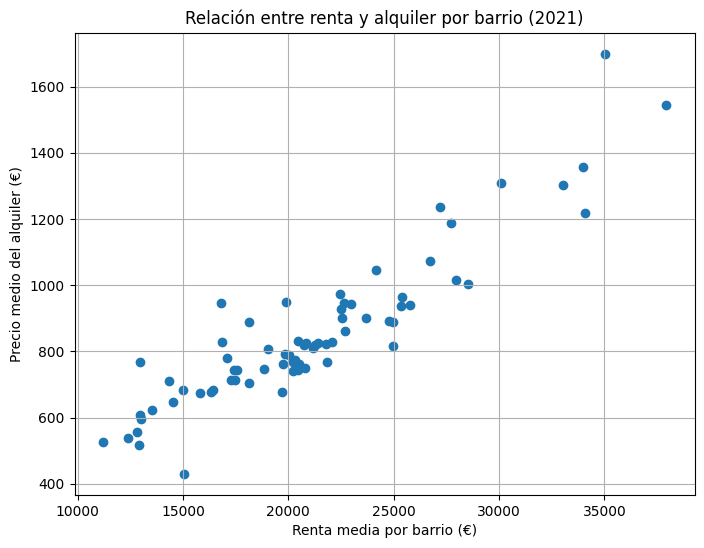

In [36]:
ultimo_año = 2021
df_plot = alquiler_renda_barris[alquiler_renda_barris["Any"] == ultimo_año]

plt.figure(figsize=(8,6))
plt.scatter(df_plot["Renda_mitjana"], df_plot["Preu_mitjà_lloguer"])
plt.xlabel("Renta media por barrio (€)")
plt.ylabel("Precio medio del alquiler (€)")
plt.title(f"Relación entre renta y alquiler por barrio ({ultimo_año})")
plt.grid(True)
plt.show()

Se observa una relación positiva entre la renta media por barrio y el precio medio alquiler.  
Algunos barrios presentan precios de alquiler altos en comparación con la renta, lo que puede indicar factores como alta demanda.

In [37]:
corr = (
    df_plot[["Preu_mitjà_lloguer", "Renda_mitjana"]]
    .corr()
    .iloc[0,1]
)
print(f"Correlación entre renta y alquiler: {corr:.2f}")


Correlación entre renta y alquiler: 0.91


# 6. Comparación crecimiento renda VS crecimiento precio alquiler

Se comparan las tendencias de crecimiento del alquiler y la renta media, independientemente de su magnitud absoluta.

In [38]:
evolució_renta

,Any,Import_Euros
0,2015,20479.089888
1,2016,21126.310861
2,2017,21332.634831
3,2018,21647.046816
4,2019,22702.258427
5,2020,21095.706929
6,2021,22166.160112


In [39]:
alquiler_medio= (
    alquiler_renda_barris
    .groupby('Any')["Preu_mitjà_lloguer"]
    .mean()
    .reset_index()
)
alquiler_medio

,Any,Preu_mitjà_lloguer
0,2015,677.714110
1,2016,731.854658
2,2017,813.253194
3,2018,852.688194
4,2019,890.781096
5,2020,890.944722
6,2021,852.180694


In [40]:
comparativa = pd.merge(
    evolució_renta,
    alquiler_medio,
    on='Any'
)

comparativa['crecimiento_renta'] = (comparativa['Import_Euros'] / comparativa['Import_Euros'].loc[0]) *100


comparativa['crecimiento_precio_lloguer'] = (comparativa['Preu_mitjà_lloguer'] / comparativa['Preu_mitjà_lloguer'].loc[0]) *100

comparativa

,Any,Import_Euros,Preu_mitjà_lloguer,crecimiento_renta,crecimiento_precio_lloguer
0,2015,20479.089888,677.714110,100.000000,100.000000
1,2016,21126.310861,731.854658,103.160399,107.988700
2,2017,21332.634831,813.253194,104.167885,119.999449
3,2018,21647.046816,852.688194,105.703168,125.818274
4,2019,22702.258427,890.781096,110.855798,131.439066
5,2020,21095.706929,890.944722,103.010959,131.463210
6,2021,22166.160112,852.180694,108.238014,125.743390


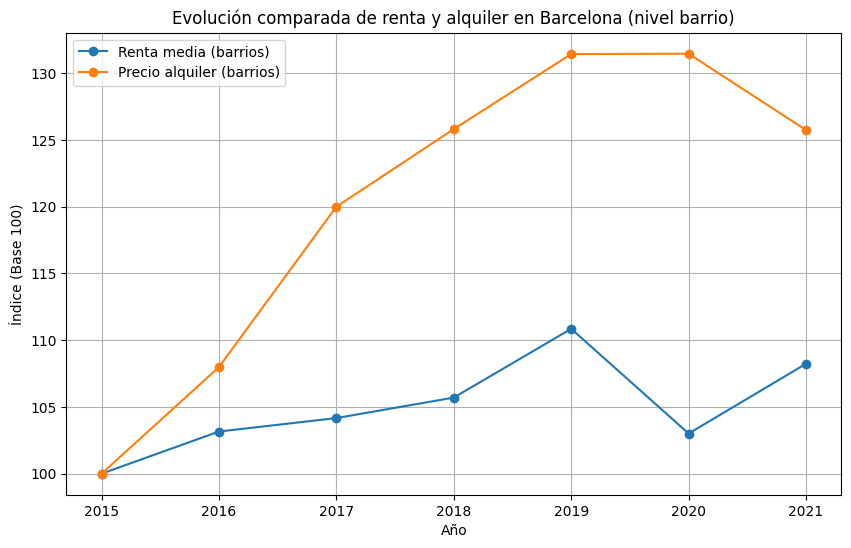

In [41]:
plt.figure(figsize=(10,6))

plt.plot(comparativa["Any"], comparativa["crecimiento_renta"], marker="o", label="Renta media (barrios)")
plt.plot(comparativa["Any"], comparativa["crecimiento_precio_lloguer"], marker="o", label="Precio alquiler (barrios)")

plt.title("Evolución comparada de renta y alquiler en Barcelona (nivel barrio)")
plt.xlabel("Año")
plt.ylabel("Índice (Base 100)")
plt.legend()
plt.grid(True)

plt.show()

El análisis se realiza a nivel de barrio, ya que permite una comparación coherente entre renta media y precio del alquiler.

Los resultados muestran que el precio del alquiler ha crecido a un ritmo superior al de la renta media, lo que implica un aumento del esfuerzo económico de los hogares en el acceso a la vivienda, especialmente en los barrios con menor nivel de renta.


# 7. Esfuerzo económico

In [42]:
alquiler_renda_barris["Alquiler_anual"] = (
    alquiler_renda_barris["Preu_mitjà_lloguer"] * 12
)
alquiler_renda_barris

,Territori,Tipus de territori,Any,Preu_mitjà_lloguer,Renda_mitjana,Alquiler_anual
0,Pedralbes,Barri,2019,1860.56,40342.71,22326.72
1,Pedralbes,Barri,2017,1785.63,37622.71,21427.56
2,Pedralbes,Barri,2018,1739.60,38523.14,20875.20
3,Pedralbes,Barri,2015,1729.95,34169.29,20759.40
4,Pedralbes,Barri,2020,1718.24,37271.00,20618.88
...,...,...,...,...,...,...
502,la Clota,Barri,2015,350.25,17412.00,4203.00
503,Baró de Viver,Barri,2015,287.39,11011.50,3448.68
504,Can Peguera,Barri,2016,253.10,12459.00,3037.20
505,Baró de Viver,Barri,2016,216.41,11420.50,2596.92


In [43]:
alquiler_renda_barris["Esfuerzo_pct"] = (
    alquiler_renda_barris["Alquiler_anual"] /
    alquiler_renda_barris["Renda_mitjana"]
) * 100

alquiler_renda_barris

,Territori,Tipus de territori,Any,Preu_mitjà_lloguer,Renda_mitjana,Alquiler_anual,Esfuerzo_pct
0,Pedralbes,Barri,2019,1860.56,40342.71,22326.72,55.342638
1,Pedralbes,Barri,2017,1785.63,37622.71,21427.56,56.953792
2,Pedralbes,Barri,2018,1739.60,38523.14,20875.20,54.188729
3,Pedralbes,Barri,2015,1729.95,34169.29,20759.40,60.754555
4,Pedralbes,Barri,2020,1718.24,37271.00,20618.88,55.321510
...,...,...,...,...,...,...,...
502,la Clota,Barri,2015,350.25,17412.00,4203.00,24.138525
503,Baró de Viver,Barri,2015,287.39,11011.50,3448.68,31.318894
504,Can Peguera,Barri,2016,253.10,12459.00,3037.20,24.377558
505,Baró de Viver,Barri,2016,216.41,11420.50,2596.92,22.739109


In [44]:
esfuerzo_any = (
    alquiler_renda_barris
    .groupby("Any")["Esfuerzo_pct"]
    .mean()
    .reset_index()
    .round(2)
)
esfuerzo_any

,Any,Esfuerzo_pct
0,2015,42.01
1,2016,44.19
2,2017,48.89
3,2018,51.03
4,2019,51.04
5,2020,54.89
6,2021,49.17


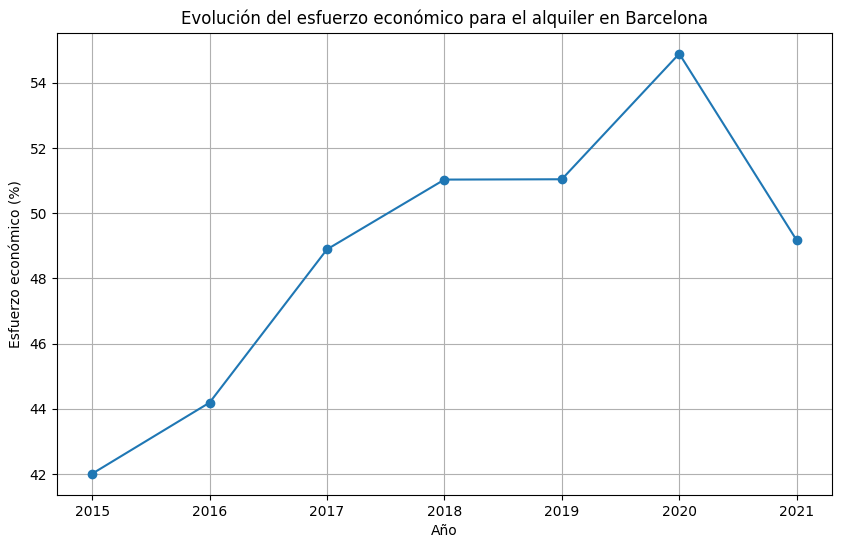

In [45]:
plt.figure(figsize=(10,6))
plt.plot(esfuerzo_any["Any"], esfuerzo_any["Esfuerzo_pct"], marker="o")

plt.title("Evolución del esfuerzo económico para el alquiler en Barcelona")
plt.xlabel("Año")
plt.ylabel("Esfuerzo económico (%)")
plt.grid(True)
plt.show()

El esfuerzo económico mide la proporción de la renta anual que los hogares destinan al pago del alquiler. 

Los resultados muestran un incremento progresivo del esfuerzo económico, lo que indica que el crecimiento del alquiler no ha ido acompañado por un aumento proporcional de la renta.


# 8. Barrios Extremos

In [46]:
barrios_extremos = ["Pedralbes", "Can Peguera"]

In [47]:
df_extremos = alquiler_renda_barris[alquiler_renda_barris["Territori"].isin(barrios_extremos)]

In [48]:
df_extremos

,Territori,Tipus de territori,Any,Preu_mitjà_lloguer,Renda_mitjana,Alquiler_anual,Esfuerzo_pct
0,Pedralbes,Barri,2019,1860.56,40342.71,22326.72,55.342638
1,Pedralbes,Barri,2017,1785.63,37622.71,21427.56,56.953792
2,Pedralbes,Barri,2018,1739.60,38523.14,20875.20,54.188729
3,Pedralbes,Barri,2015,1729.95,34169.29,20759.40,60.754555
4,Pedralbes,Barri,2020,1718.24,37271.00,20618.88,55.321510
5,Pedralbes,Barri,2021,1699.09,35018.57,20389.08,58.223622
7,Pedralbes,Barri,2016,1661.83,36871.71,19941.96,54.084717
486,Can Peguera,Barri,2018,439.63,12951.50,5275.56,40.733197
491,Can Peguera,Barri,2019,419.43,13109.50,5033.16,38.393226
492,Can Peguera,Barri,2017,417.84,12527.00,5014.08,40.026183


In [49]:
( df_extremos
.groupby('Territori')['Renda_mitjana']
.mean()
.round(2)
.reset_index()
.sort_values(by='Renda_mitjana', ascending=False)
)

,Territori,Renda_mitjana
1,Pedralbes,37117.02
0,Can Peguera,12565.92


In [50]:
( df_extremos
.groupby('Territori')['Preu_mitjà_lloguer']
.mean()
.round(2)
.reset_index()
.sort_values(by='Preu_mitjà_lloguer', ascending=False)
)

,Territori,Preu_mitjà_lloguer
1,Pedralbes,1742.13
0,Can Peguera,351.15


In [51]:
esfuerzo_extremos = ( df_extremos
.groupby(['Territori','Any'])['Esfuerzo_pct']
.mean()
.round(2)
.reset_index()
.sort_values(by='Territori')
)

esfuerzo_extremos

,Territori,Any,Esfuerzo_pct
0,Can Peguera,2015,20.86
1,Can Peguera,2016,24.38
2,Can Peguera,2017,40.03
3,Can Peguera,2018,40.73
4,Can Peguera,2019,38.39
5,Can Peguera,2020,35.99
6,Pedralbes,2015,60.75
7,Pedralbes,2016,54.08
8,Pedralbes,2017,56.95
9,Pedralbes,2018,54.19


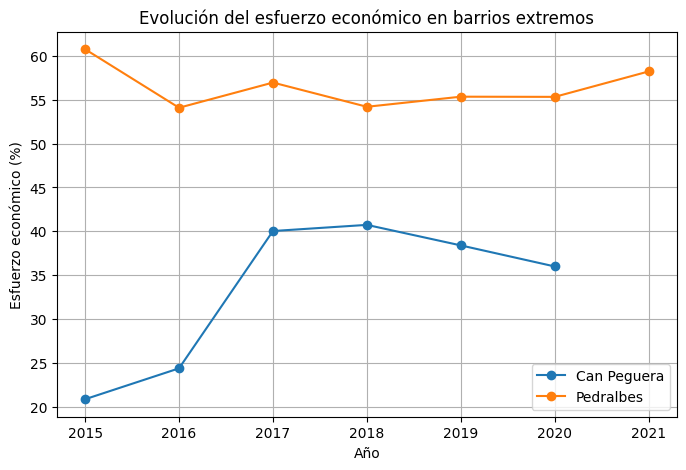

In [52]:
plt.figure(figsize=(8,5))


for barrio in esfuerzo_extremos['Territori'].unique():
    datos_barrio = esfuerzo_extremos[esfuerzo_extremos['Territori'] == barrio]
    plt.plot(datos_barrio['Any'], datos_barrio['Esfuerzo_pct'], marker='o', label=barrio)

plt.xlabel('Año')
plt.ylabel('Esfuerzo económico (%)')
plt.title('Evolución del esfuerzo económico en barrios extremos')
plt.legend()
plt.grid(True)
plt.show()



Se han identificado los barrios con el alquiler más alto y más bajo en Barcelona:

- **Barrio más caro**: Pedralbes (1762,67 €)
- **Barrio más barato**: Can Peguera (362,46 €)

A continuación, se ha comparado la **renta media** de estos barrios:

- Pedralbes: 37.117 €  
- Can Peguera: 12.566 €

Con estos datos se ha calculado el **esfuerzo económico**: porcentaje de la renta anual destinado al alquiler.  
Se observa que:

- Pedralbes, aunque con renta alta, tiene un esfuerzo económico alrededor del 55-60%.  
- Can Peguera, con renta baja, tiene un esfuerzo que sube hasta ~40% en algunos años.
  
La carga económica ha aumentado más en los barrios con menor renta, afectando proporcionalmente más a los hogares más pobres.  
En los barrios de renta alta, aunque el alquiler es elevado, el porcentaje de renta destinado al alquiler se mantiene más estable.  
Esto evidencia que el aumento del precio del alquiler impacta de manera desproporcionada a los hogares con menores ingresos.




